In [11]:
import minisynth
from IPython.display import display, Audio
import tqdm
import numpy as np
import utils
import pandas as pd

import matplotlib.pyplot as plt

import h5py

In [12]:
SAMPLE_RATE = 44100

In [13]:
synth = minisynth.MiniSynthSubtractive(sr=SAMPLE_RATE)
audio = synth.render()

display(Audio(audio, rate=SAMPLE_RATE, autoplay=True))


In [14]:
dataset = minisynth.DatasetManager(synth)
dataset.read_dataset("dataset.json")

In [15]:
REPR = "spectrum"

def create_dataset_repr(REPR):
    with h5py.File(f'reprs_{REPR}.h5', 'w') as f:
        for i in tqdm.tqdm(range(1000), desc="Processing audio"):
            audio = dataset.get_audio(i)
            audio = audio.copy()
            repr = utils.calc_representation(audio, sr=SAMPLE_RATE, repr=REPR)
            
            # Save directly to file
            f.create_dataset(str(i), data=repr)

# create_dataset_repr(REPR)

In [16]:
def load_repr(filename, i):
    with h5py.File(filename, 'r') as f:
        return f[str(i)][:]

# # Load all (if needed)
def load_all_reprs(filename):
    reprs = {}
    with h5py.File(filename, 'r') as f:
        for key in f.keys():
            reprs[int(key)] = f[key][:]
    return reprs

def get_h5_keys(filename):
    with h5py.File(filename, 'r') as f:
        return list(f.keys())

In [17]:
def find_active_modulations(points, threshold=1e-15):
    active_modulations = []
    for mod, data in points.items():
        if is_active_modulation(data, threshold):
            active_modulations.append(mod)
    return active_modulations

def is_active_modulation(data:np.ndarray, threshold=1e-15):
    """
    Check if a modulation is active based on its data.
    A modulation is considered active if its the difference between the maximum and minimum values is greater than the threshold.
    """
    return np.max(data[1]) - np.min(data[1]) > threshold


def calc_depth(points, parameter):
    parameter_scale = parameter["scale"]
    parameter_range = parameter["range"]

    points_range = (np.min(points[1]), np.max(points[1]))

    if parameter_scale == minisynth.Scale.LOGARITHMIC:
        depth = np.log10(points_range[1] / points_range[0]) / np.log10(parameter_range[1] / parameter_range[0])
    else:
        depth = (points_range[1] - points_range[0]) / (parameter_range[1] - parameter_range[0])

    return depth


In [18]:
def calc_dataset_entry_correlations(i:int, dataset:minisynth.DatasetManager, REPR_path:str, metrics_ids:list, params:list, length:int=44100) -> dict:
    
    """
    Calculate correlations for a single dataset entry.
    Args:
        i (int): Index of the dataset entry.
        dataset (DatasetManager): The dataset manager instance.
        REPR_path (str): Path to the representation file.
        metrics_ids (list): List of metric IDs to calculate.
        params (dict): Parameters for modulation depth calculation.
        length (int): Length of the output arrays.
    Returns:
        dict: A dictionary with correlations and modulation depths.
    """
    
    active_modulations = find_active_modulations(dataset.get_plot_points(i))

    # get representation
    repr = load_repr(REPR_path, i)

    # loop through and calculate metrics, normalized and with smoothing
    metrics = {}
    for metric_id in metrics_ids:
        metric = utils.calc_metric(repr, metric_id)
        metric = utils.norm_stretch(metric, length)
        metric = utils.smooth(metric, 1000)
        metrics[metric_id] = metric

    # modulations processing
    modulations = dataset.get_modulation(i)
    depths = {f'{key}_depth': calc_depth(mod, params[key]) for key, mod in dataset.get_plot_points(i).items()}
    modulations = {key: utils.norm_stretch(mod, length) for key, mod in modulations.items()}

    # loop through modulations and metrics, get the line and calculate correlation
    correlations = {}
    
    for metric_id in metrics_ids:
        for mod_id in modulations.keys():
            label = f'{metric_id}_{mod_id}'
            if mod_id not in active_modulations:
                correlations[label] = None
            else:
                correlations[label] = utils.calc_correlation(modulations[mod_id], metrics[metric_id])

    return {**correlations, **depths}
    

In [19]:
# REPR = 'mfcc'
length = 44100
metrics_ids = utils.get_available_metrics()
params = synth.get_parameters()

# dataset_entries = []

# for i in tqdm.tqdm(range(1000)):
#     dataset_entries.append(calc_dataset_entry_correlations(
#         i, dataset, f'reprs_{REPR}.h5', metrics_ids, params, length=length
#     ))

# df = pd.DataFrame(dataset_entries)

# df.to_csv(f'{REPR}-correlations.csv', index=False)

# display(df)

In [20]:
REPR = 'mfcc'


df = pd.read_csv(f'{REPR}-correlations.csv')

# columns absolute value
df_abs = df.abs()

# average over all metrics for the first 250
df_avg = df_abs.iloc[:250].mean(axis=0)
display(df_avg)

magnitude_base_freq                0.286806
magnitude_amp                      0.852018
magnitude_filter_cutoff            0.896037
magnitude_osc_shape                0.710276
distances_base_freq                0.283367
distances_amp                      0.119990
distances_filter_cutoff            0.120618
distances_osc_shape                0.188492
cosine_similarity_base_freq        0.187159
cosine_similarity_amp              0.161811
cosine_similarity_filter_cutoff    0.144804
cosine_similarity_osc_shape        0.131752
base_freq_depth                    0.054197
amp_depth                          0.084366
filter_cutoff_depth                0.073351
osc_shape_depth                    0.064347
dtype: float64

# Plot function to visualize the results


In [21]:
def plot_metric_correlation_scatter(ax, df, param="amp", title=None):
    ax.plot(df[f"{param}_depth"], df[f"magnitude_{param}"], 'o', label='Magnitude', alpha=0.7)
    ax.plot(df[f"{param}_depth"], df[f"cosine_similarity_{param}"], 'o', label='Cosine Similarity', alpha=0.7)
    ax.plot(df[f"{param}_depth"], df[f"distances_{param}"], 'o', label='Distances', alpha=0.7)
    ax.set_xlabel(f"{param.capitalize()} Depth")
    ax.set_ylabel("Metric Correlation")
    if title:
        ax.set_title(title)
    # ax.legend()

def create_plot_grid(df, param="amp"):
    fig, axes = plt.subplots(2, 2, figsize=(6, 6))
    axes = axes.flatten()
    
    ranges = [(0, 250), (250, 500), (500, 750), (750, 1000)]
    
    for i, (start, end) in enumerate(ranges):
        plot_metric_correlation_scatter(
            axes[i], 
            df.iloc[start:end], 
            param=param, 
            title=f"Samples {start}-{end-1}"
        )
    
    plt.legend(loc='lower right', bbox_to_anchor=(1.2, 1))
    plt.tight_layout()
    plt.show()


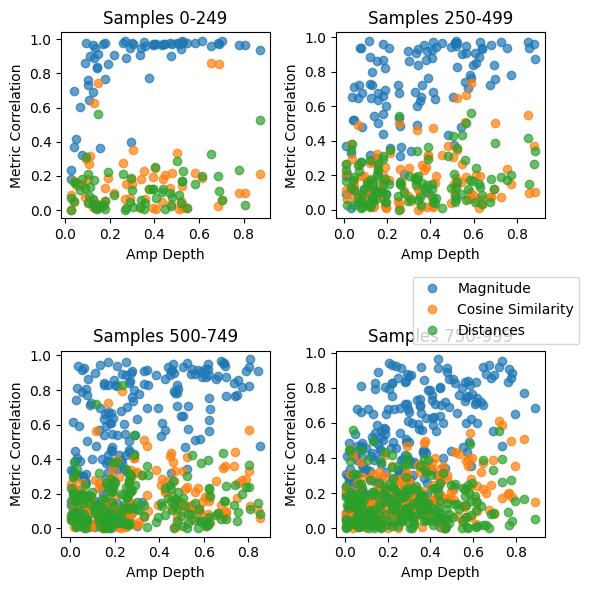

In [22]:
create_plot_grid(df_abs,  param="amp")


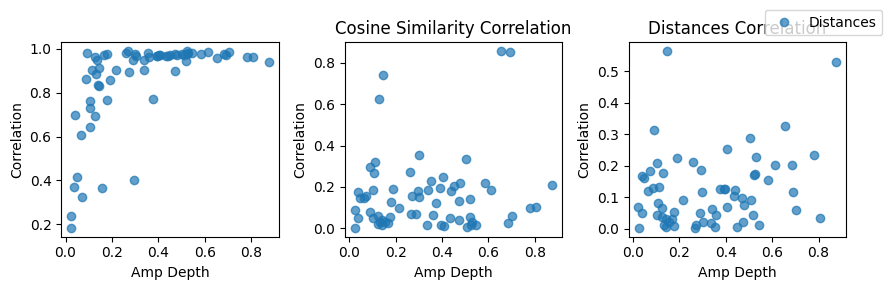

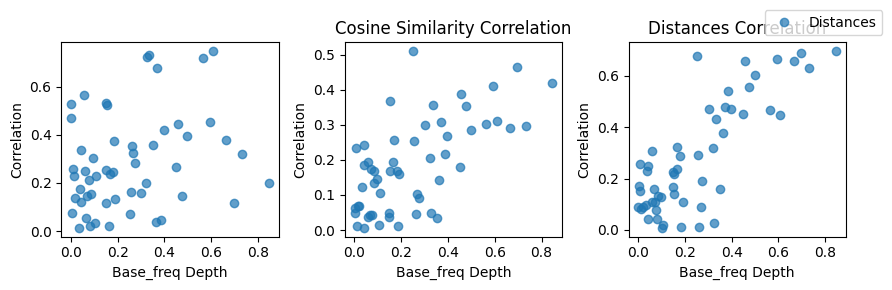

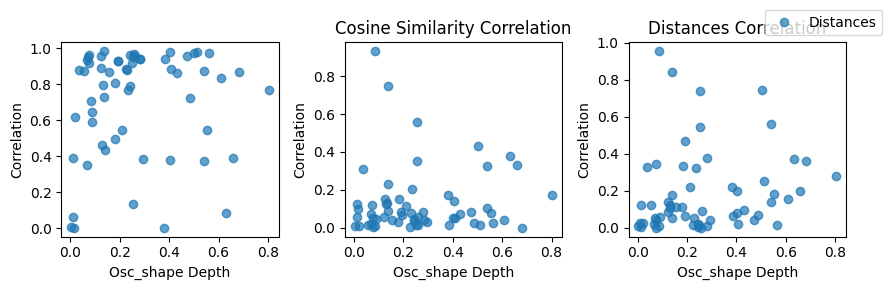

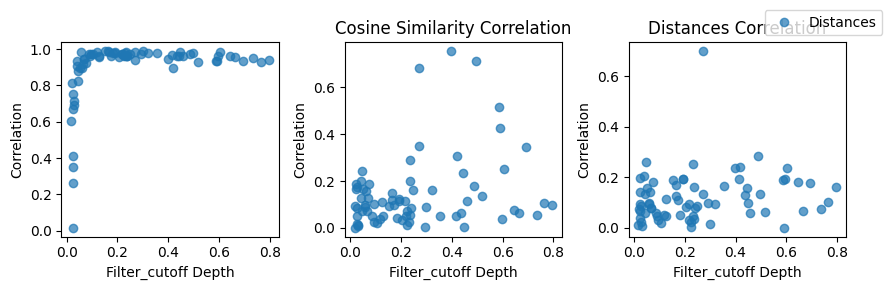

In [23]:

def plot_metric_correlation_scatter(ax, df, param="amp", title=None):
    ax[0].plot(df[f"{param}_depth"], df[f"magnitude_{param}"], 'o', label='Magnitude', alpha=0.7)
    ax[0].set_xlabel(f"{param.capitalize()} Depth")
    ax[0].set_ylabel("Correlation")

    ax[1].plot(df[f"{param}_depth"], df[f"cosine_similarity_{param}"], 'o', label='Cosine Similarity', alpha=0.7)
    
    ax[1].set_title("Cosine Similarity Correlation")
    # ax[1].set_xlim(1.0)
    # ax[1].set_ylim(1.0)
    ax[1].set_xlabel(f"{param.capitalize()} Depth")
    ax[1].set_ylabel("Correlation")

    ax[2].plot(df[f"{param}_depth"], df[f"distances_{param}"], 'o', label='Distances', alpha=0.7)
    ax[2].set_title("Distances Correlation")
    ax[2].set_xlabel(f"{param.capitalize()} Depth")
    ax[2].set_ylabel("Correlation")

def create_plot_grid(df, ranges ,param="amp"):
    fig, axes = plt.subplots(1,3, figsize=(9, 3))
    
    for i, (start, end) in enumerate(ranges):
        plot_metric_correlation_scatter(
            axes, 
            df.iloc[start:end], 
            param=param, 
            title=f"Samples {start}-{end-1}"
        )
    
    plt.legend(loc='lower right', bbox_to_anchor=(1.2, 1))
    plt.tight_layout()
    plt.show()


create_plot_grid(df_abs, ranges=[(0,250)], param="amp")
create_plot_grid(df_abs, ranges=[(0,250)], param="base_freq")
create_plot_grid(df_abs, ranges=[(0,250)], param="osc_shape")
create_plot_grid(df_abs, ranges=[(0,250)], param="filter_cutoff")
# create_plot_grid(df_abs, ranges=[(750, 1000)], param="amp")

In [24]:
def calc_dataset_entry_component(i:int, dataset:minisynth.DatasetManager, REPR:str, params:dict) -> dict:
    active_modulations = find_active_modulations(dataset.get_plot_points(i))

    # get representation
    repr = load_repr(f'reprs_{REPR}.h5', i)

    # modulations processing
    modulations = dataset.get_modulation(i)
    depths = {f'{key}_depth': calc_depth(mod, params[key]) for key, mod in dataset.get_plot_points(i).items()}

    components = {}
    correlations = {}

    for mod_id in modulations.keys():
        if mod_id not in active_modulations:
            continue

        repr_T = repr.T.astype(np.float32)
        mod_repr_sized = utils.norm_stretch(modulations[mod_id], repr_T.shape[0])

        w, residual, rank, s = np.linalg.lstsq(repr_T, mod_repr_sized, rcond=None)
        components[f"{mod_id}_component"] = w
        correlations[f"{mod_id}_correlelation"] = utils.calc_correlation(repr_T @ w, mod_repr_sized)

    return {**components, **correlations, **depths}


In [25]:
REPR = 'music2latent'
metrics_ids = utils.get_available_metrics()
params = synth.get_parameters()

dataset_entries = []

for i in tqdm.tqdm(range(1000)):

    dataset_entries.append(
        calc_dataset_entry_component(
            i, dataset, REPR, params
        )
    )
    
df_components = pd.DataFrame(dataset_entries)
df_components.to_parquet(f'{REPR}-components.parquet', index=False)
display(df_components)

  5%|▍         | 49/1000 [00:05<01:55,  8.20it/s]


KeyboardInterrupt: 

In [118]:
REPR = "cqt"
PARAM = "filter_cutoff"

In [119]:
def get_componets_array(df_column):
    """
    Convert a DataFrame column of string representations of arrays into a numpy array.
    """
    # exclude nans
    df_column = df_column.dropna()
    return np.array([np.fromstring(x[1:-1], sep=' ') for x in df_column])

def filter_components_column(vectors: np.ndarray, threshold: float = 3.0) -> np.ndarray:
    norms = np.linalg.norm(vectors, axis=1)

    z_scores = (norms - np.mean(norms)) / np.std(norms)

    threshold = 3
    mask = np.abs(z_scores) < threshold

    filtered_vectors = vectors[mask]

    return filtered_vectors

def deactivate_low_depth_components(df, theshold = 0.1):
    for col in df.columns:
        if col.endswith('_depth'):
            # get the corresponding component column
            component_col = col.replace('_depth', '_component')
            correlation_col = col.replace('_depth', '_correlelation')
            if component_col in df.columns:
                # set vector component to None if depth is below threshold
                df.loc[df[col] < theshold, component_col] = None
            if correlation_col in df.columns:
                # set correlation to None if depth is below threshold
                df.loc[df[col] < theshold, correlation_col] = np.nan
    return df



(84, 862)


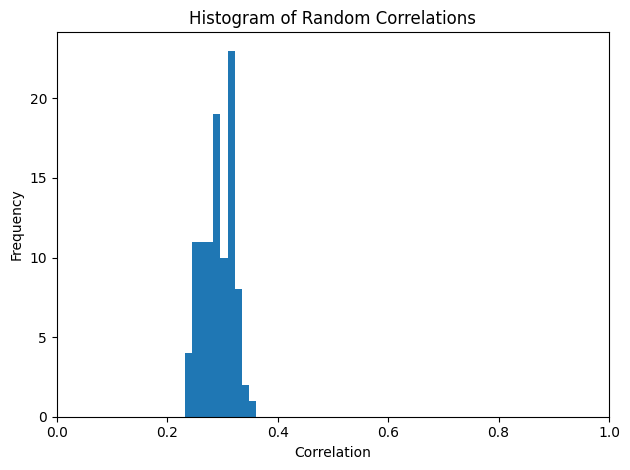

In [120]:
repr = load_repr(f'reprs_{REPR}.h5', 1)

print(repr.shape)
# test with random data
correlations = []
for i in range(100):
    random_repr = np.random.rand(repr.shape[0], repr.shape[1])
    random_mod_repr = np.random.rand(repr.shape[1])
    
    w, residual, rank, s = np.linalg.lstsq(random_repr.T, random_mod_repr, rcond=None)
    correlation = utils.calc_correlation(random_repr.T @ w, random_mod_repr)
    correlations.append(correlation)

plt.hist(correlations, bins=10)
plt.xlabel("Correlation")
plt.ylabel("Frequency")
plt.title("Histogram of Random Correlations")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

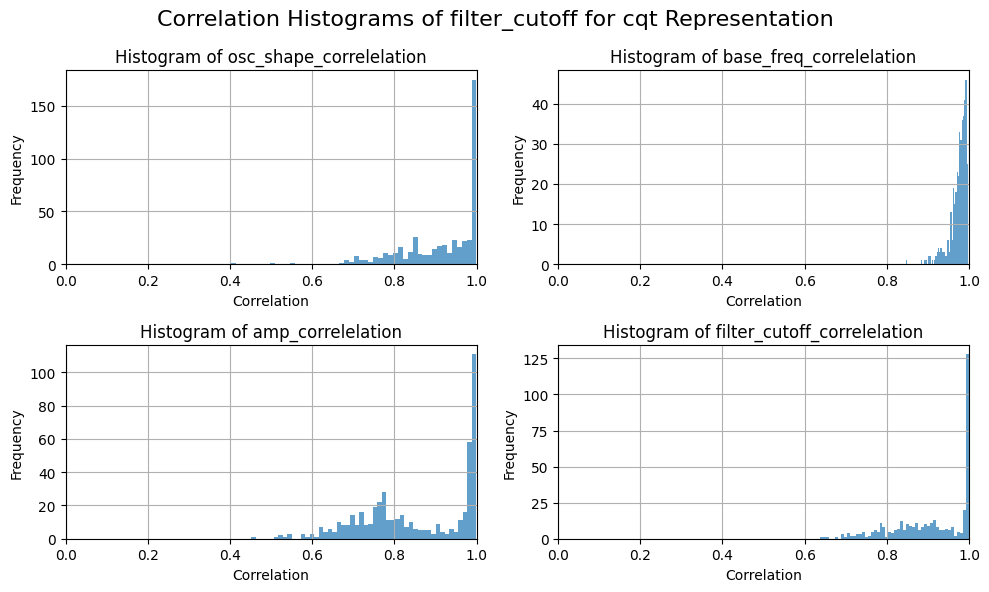

In [121]:
df_components = pd.read_parquet(f'{REPR}-components.parquet')
df_components = deactivate_low_depth_components(df_components)


correlation_cols = [col for col in df_components.columns if col.endswith('_correlelation')]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()
fig.suptitle(f'Correlation Histograms of {PARAM} for {REPR} Representation', fontsize=16)

for i, col in enumerate(correlation_cols):
    if i < 4:
        ax = axes[i]
        data = df_components[col].dropna()
        ax.hist(data, bins=50, alpha=0.7)
        ax.set_title(f'Histogram of {col}')
        ax.set_xlabel('Correlation')
        ax.set_ylabel('Frequency')
        ax.set_xlim(0, 1)
        ax.grid(True)

for i in range(len(correlation_cols), 4):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
        

array([[ 1.88327408e-03, -8.90688243e-05,  1.37319516e-04, ...,
        -2.74989642e-04, -5.55600417e-03,  3.02001025e-01],
       [-1.84467777e-04,  8.86114905e-05,  2.89640049e-04, ...,
        -1.34259619e-02,  6.63596525e-05,  1.02011945e-02],
       [ 7.96848967e-04, -7.76802650e-04, -1.16993157e-03, ...,
         6.62631257e-04,  8.33359368e-03, -5.52727326e-03],
       ...,
       [-1.50755368e-03, -2.70175602e-05, -2.05161861e-03, ...,
         1.80598146e-03,  2.23008941e-02,  4.43297471e-03],
       [-5.43564642e-03, -1.74954297e-03, -3.68177520e-03, ...,
         3.75691567e-03, -1.13313698e-04,  8.83458421e-04],
       [-3.29705857e-03, -6.98757258e-03,  2.35480211e-03, ...,
         5.29951399e-03,  1.34549280e-03,  4.49980319e-03]])

<class 'numpy.ndarray'> (401, 84)
(401, 84) (395, 84)


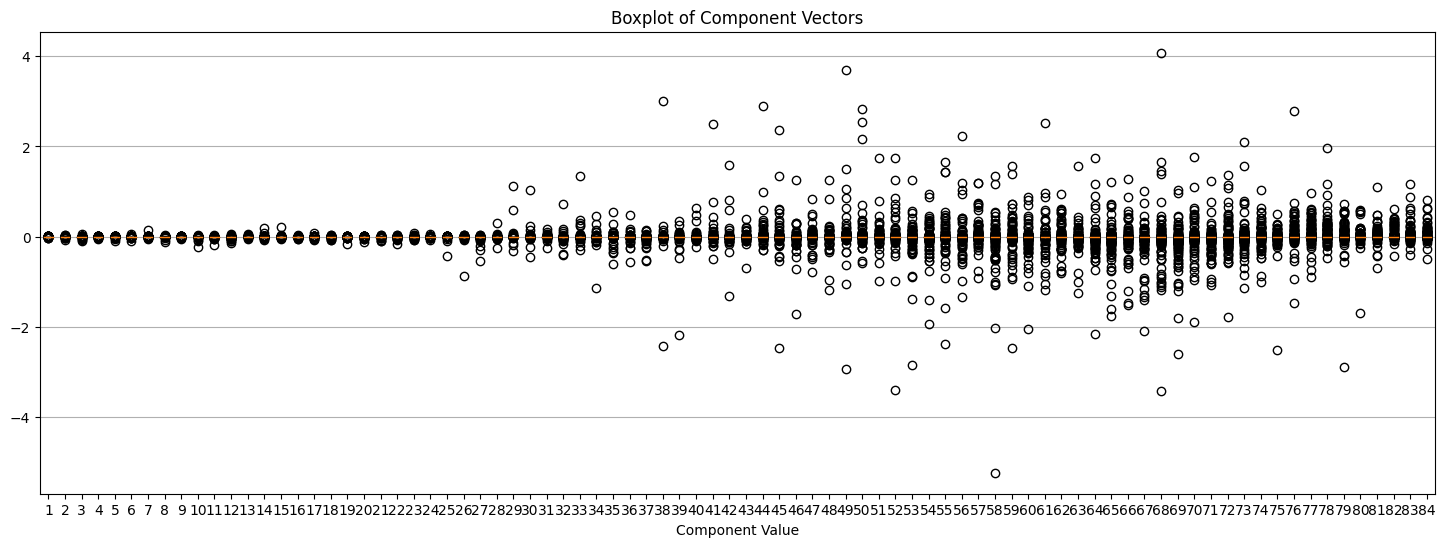

In [122]:
df_components = pd.read_parquet(f'{REPR}-components.parquet')

df_components = deactivate_low_depth_components(df_components)

vectors = df_components[f'{PARAM}_component'].dropna()
vectors = np.vstack(vectors)

display(vectors)
print(type(vectors), vectors.shape)

filtered_vectors = filter_components_column(vectors)

print(vectors.shape, filtered_vectors.shape)

#boxplot
plt.figure(figsize=(18, 6))
plt.boxplot(filtered_vectors)
plt.title('Boxplot of Component Vectors')
plt.xlabel('Component Value')
plt.grid(axis='y')
plt.show()

avg = np.mean(filtered_vectors, axis=0)

In [123]:
def find_max_n(array, n=10):
    """
    Find the indices of the top n maximum values in a numpy array.
    """
    return np.argsort(array)[-n:][::-1]

max_indices = find_max_n(np.abs(avg), n=10)
print("Indices of Top 10 Maximum Values:", max_indices)
print("Top 10 Maximum Values:", avg[max_indices])

#zero out the rest
avg_filtered = np.zeros_like(avg)
avg_filtered[max_indices] = avg[max_indices]


Indices of Top 10 Maximum Values: [68 66 57 77 49 76 64 70 75 82]
Top 10 Maximum Values: [-0.03741197 -0.02878862 -0.02849489  0.02746288  0.0220919   0.01940264
 -0.01933288 -0.01813963  0.01776658  0.01748342]


In [124]:
def calc_all_correlations(vec, REPR_path, mod_id, size=1000):
    correlations = []
    
    skipped = 0
    for i in tqdm.tqdm(range(size), desc="Calculating correlations"):
        repr = load_repr(REPR_path, i)
        modulations = dataset.get_modulation(i)
        
        if not is_active_modulation(dataset.get_plot_points(i)[mod_id]):
            skipped += 1
            continue
            
        mod_repr_sized = utils.norm_stretch(modulations[mod_id], repr.shape[0])

        test = repr.T @ vec
        correlation = utils.calc_correlation(test, mod_repr_sized)
        correlations.append(correlation)

    if skipped > 0:
        print(f"Skipped {skipped} entries due to inactive modulation.")
    return np.array(correlations)   

# random_vec = np.random.randn(avg_filtered.shape[0])

# correlations = calc_all_correlations(avg, f'reprs_{REPR}.h5', PARAM)

In [125]:

def plot_correlation_histogram(correlations, title="Correlation Distribution"):
    correlations_distribution = np.abs(correlations)
    plt.figure(figsize=(10, 6))
    plt.hist(correlations_distribution, bins=50, alpha=0.7, color='blue')
    plt.title(title)
    plt.xlabel('Correlation')
    plt.ylabel('Frequency')
    plt.grid(axis='y')
    plt.show()

# plot_correlation_histogram(correlations, title=f"Correlation Distribution for {PARAM} Component and {REPR} Representation")

In [126]:
REPR = "spectrum"
PARAM = "amp"

correlations = calc_all_correlations(avg_filtered, f'reprs_{REPR}.h5', PARAM)
plot_correlation_histogram(correlations, title=f"Correlation Distribution for {PARAM} Component and {REPR} Representation")

Calculating correlations:   0%|          | 3/1000 [00:00<01:09, 14.35it/s]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 84 is different from 2049)

Processing dac for parameter base_freq
Vectors shape: (417, 72)
Average vector shape: (72,)


Calculating correlations: 100%|██████████| 1000/1000 [01:05<00:00, 15.17it/s]


Skipped 387 entries due to inactive modulation.


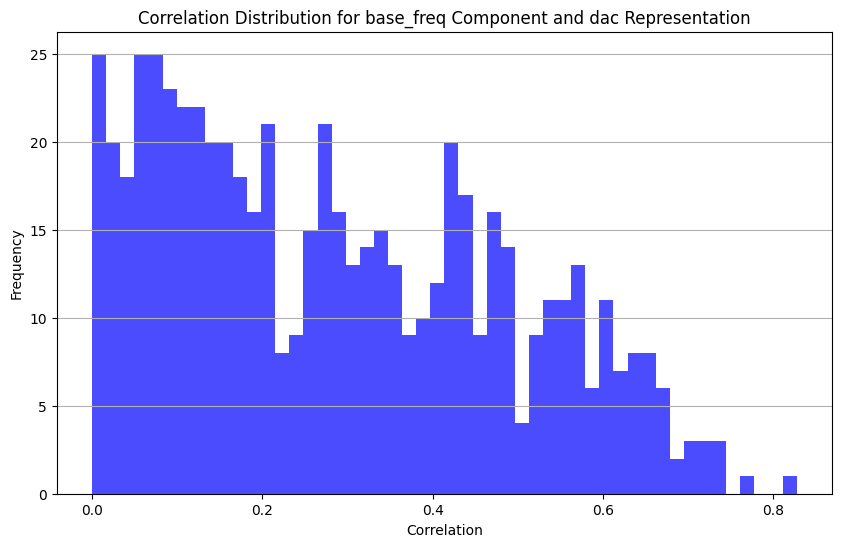

Processing dac for parameter amp
Vectors shape: (498, 72)
Average vector shape: (72,)


Calculating correlations: 100%|██████████| 1000/1000 [01:11<00:00, 14.07it/s]


Skipped 366 entries due to inactive modulation.


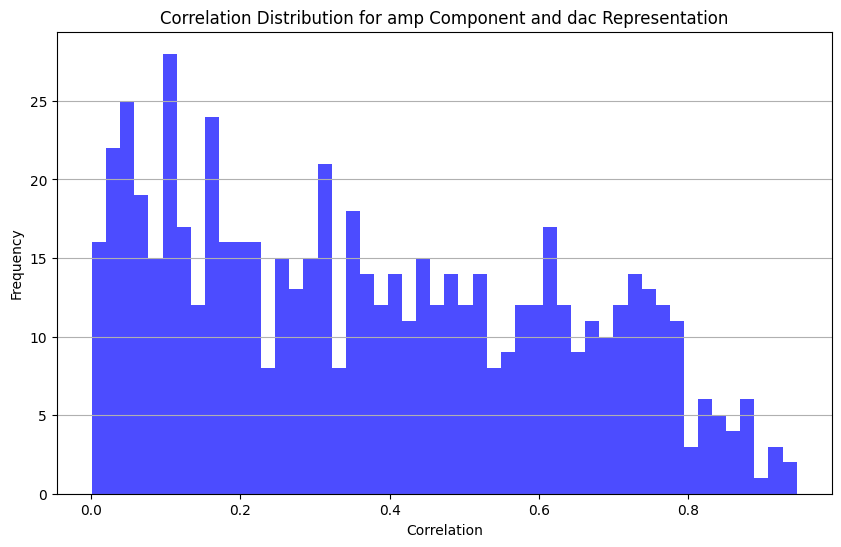

Processing dac for parameter filter_cutoff
Vectors shape: (401, 72)
Average vector shape: (72,)


Calculating correlations: 100%|██████████| 1000/1000 [01:12<00:00, 13.77it/s]


Skipped 374 entries due to inactive modulation.


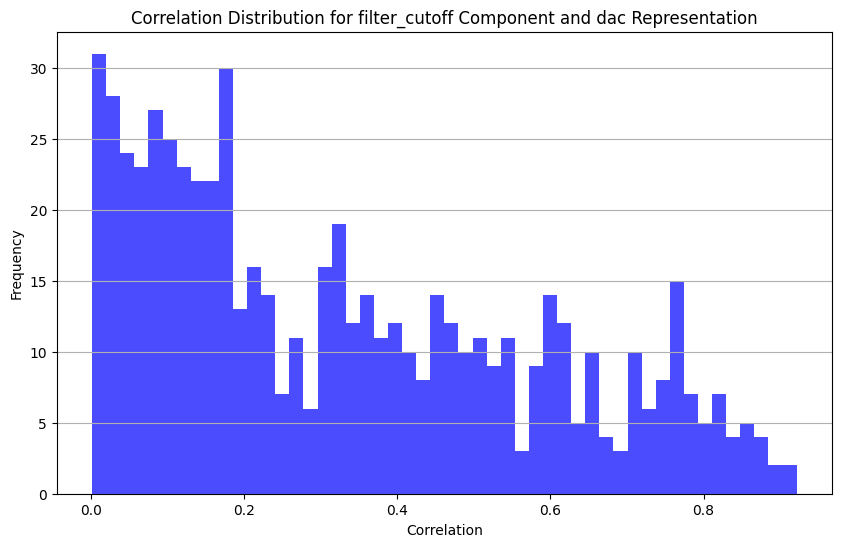

Processing dac for parameter osc_shape
Vectors shape: (478, 72)
Average vector shape: (72,)


Calculating correlations: 100%|██████████| 1000/1000 [01:13<00:00, 13.68it/s]


Skipped 373 entries due to inactive modulation.


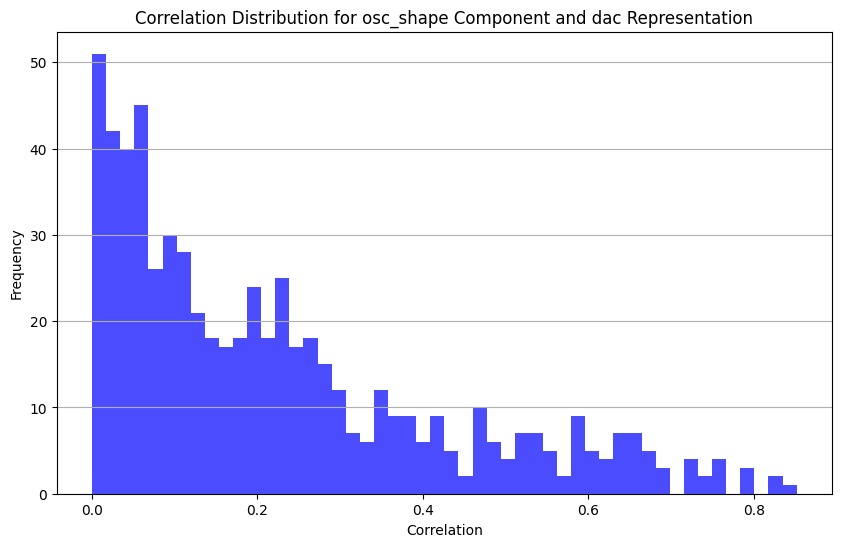

Processing mfcc for parameter base_freq
Vectors shape: (417, 20)
Average vector shape: (20,)


Calculating correlations: 100%|██████████| 1000/1000 [01:12<00:00, 13.76it/s]


Skipped 387 entries due to inactive modulation.


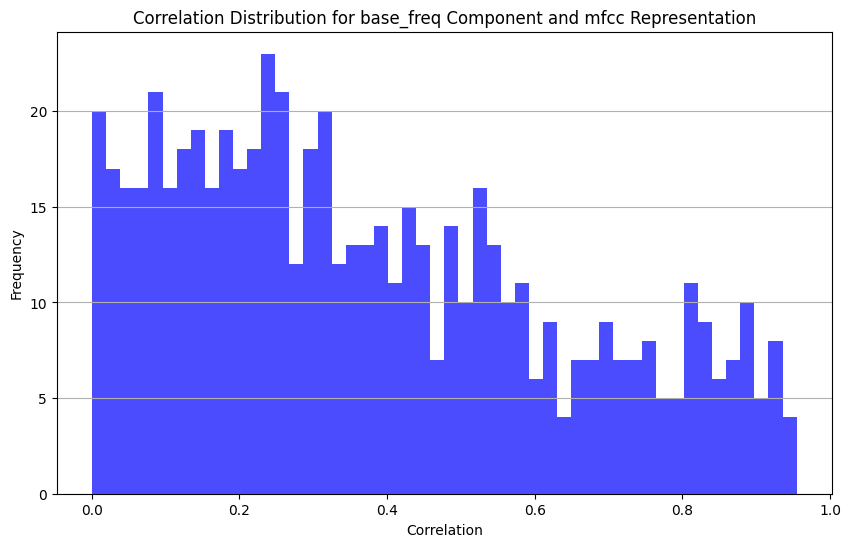

Processing mfcc for parameter amp
Vectors shape: (498, 20)
Average vector shape: (20,)


Calculating correlations: 100%|██████████| 1000/1000 [01:13<00:00, 13.59it/s]

Skipped 366 entries due to inactive modulation.


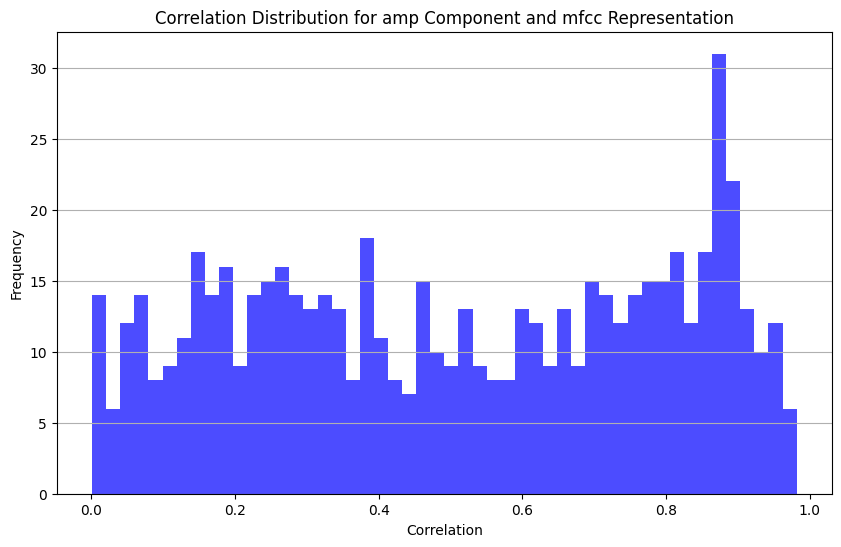

Processing mfcc for parameter filter_cutoff
Vectors shape: (401, 20)
Average vector shape: (20,)


Calculating correlations: 100%|██████████| 1000/1000 [01:13<00:00, 13.52it/s]

Skipped 374 entries due to inactive modulation.


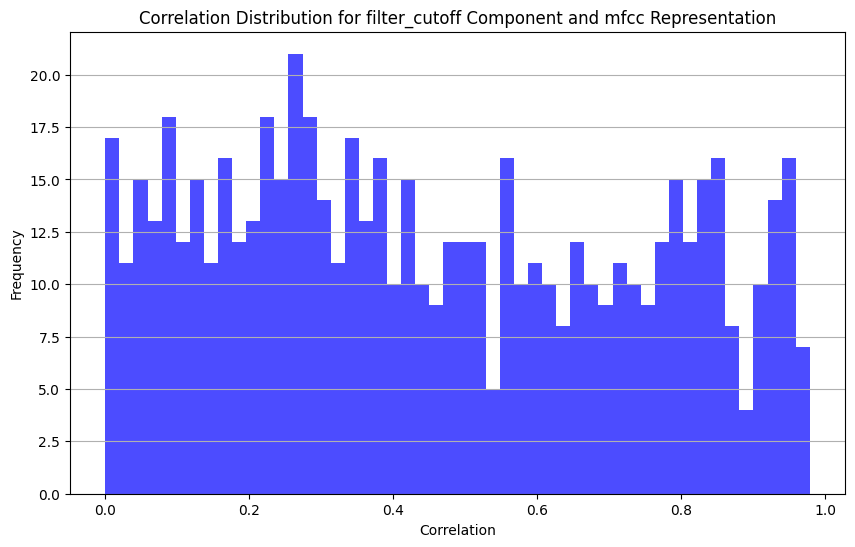

Processing mfcc for parameter osc_shape
Vectors shape: (478, 20)
Average vector shape: (20,)


Calculating correlations: 100%|██████████| 1000/1000 [01:14<00:00, 13.45it/s]


Skipped 373 entries due to inactive modulation.


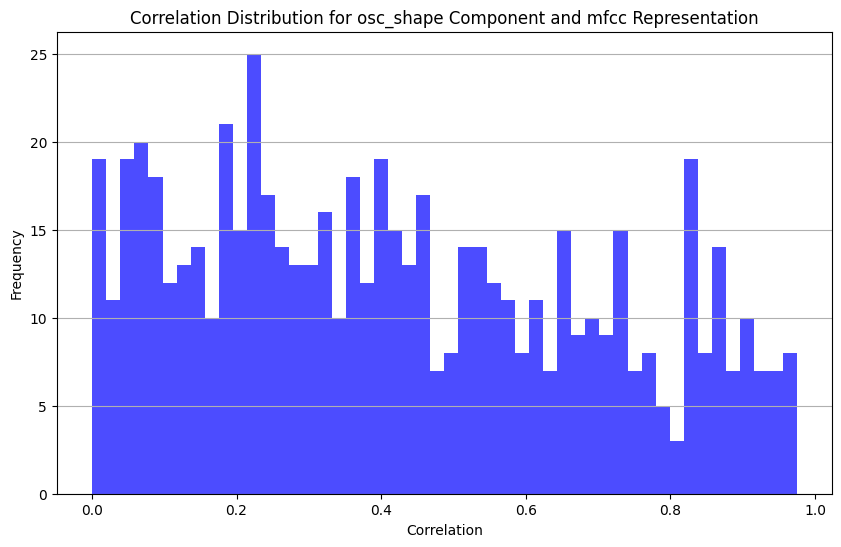

Processing music2latent for parameter base_freq
Vectors shape: (417, 64)
Average vector shape: (64,)


Calculating correlations: 100%|██████████| 1000/1000 [01:13<00:00, 13.63it/s]


Skipped 387 entries due to inactive modulation.


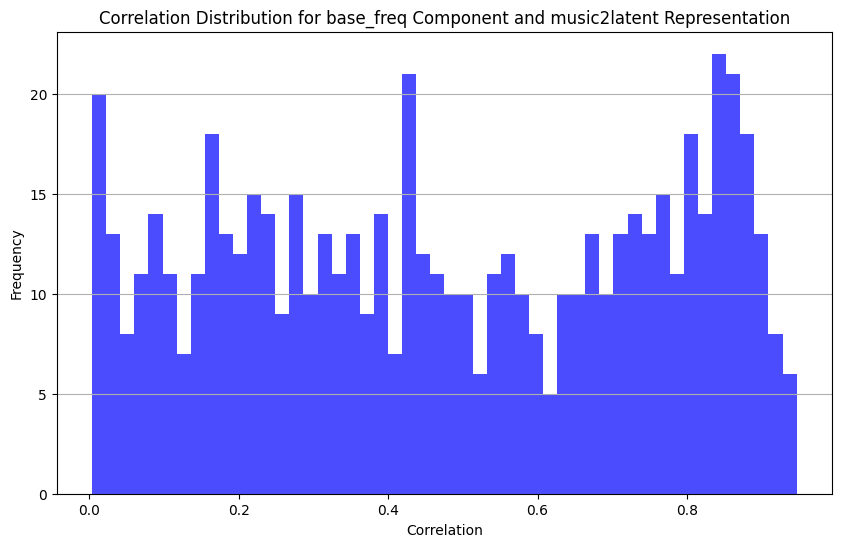

Processing music2latent for parameter amp
Vectors shape: (498, 64)
Average vector shape: (64,)


Calculating correlations: 100%|██████████| 1000/1000 [01:14<00:00, 13.33it/s]


Skipped 366 entries due to inactive modulation.


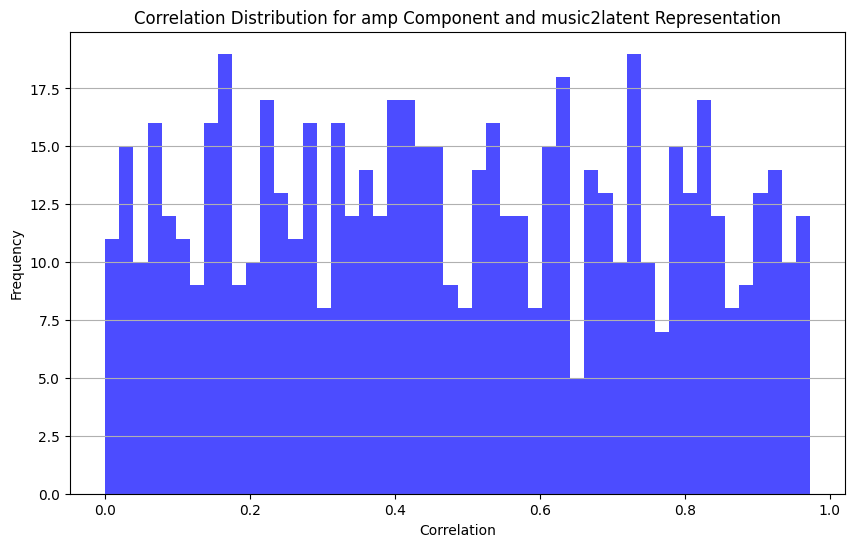

Processing music2latent for parameter filter_cutoff
Vectors shape: (401, 64)
Average vector shape: (64,)


Calculating correlations: 100%|██████████| 1000/1000 [01:14<00:00, 13.50it/s]


Skipped 374 entries due to inactive modulation.


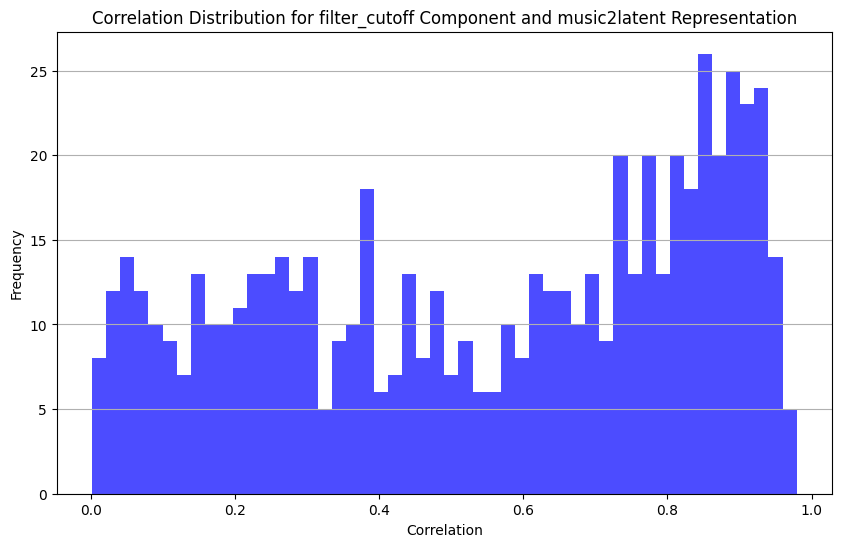

Processing music2latent for parameter osc_shape
Vectors shape: (478, 64)
Average vector shape: (64,)


Calculating correlations: 100%|██████████| 1000/1000 [01:13<00:00, 13.59it/s]


Skipped 373 entries due to inactive modulation.


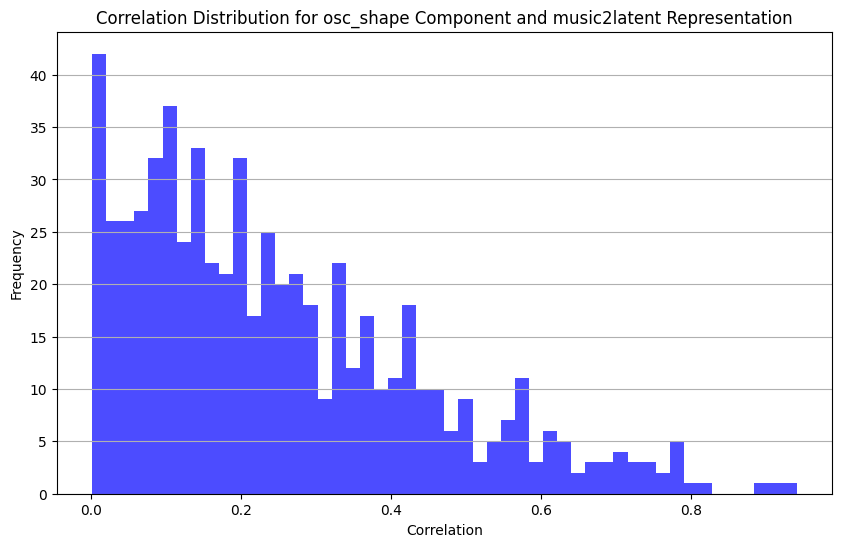

Processing spectrum for parameter base_freq
Vectors shape: (417, 2049)
Average vector shape: (2049,)


Calculating correlations: 100%|██████████| 1000/1000 [01:38<00:00, 10.14it/s]


Skipped 387 entries due to inactive modulation.


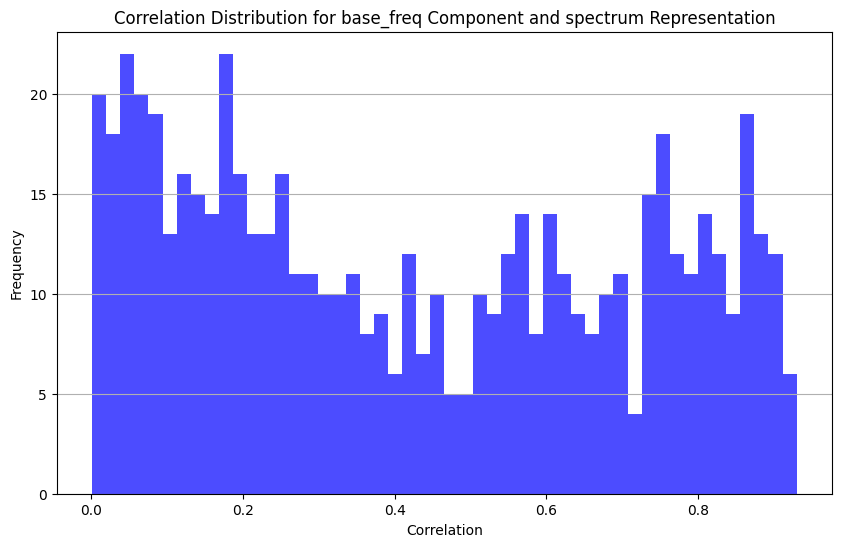

Processing spectrum for parameter amp
Vectors shape: (498, 2049)
Average vector shape: (2049,)


Calculating correlations: 100%|██████████| 1000/1000 [01:37<00:00, 10.21it/s]


Skipped 366 entries due to inactive modulation.


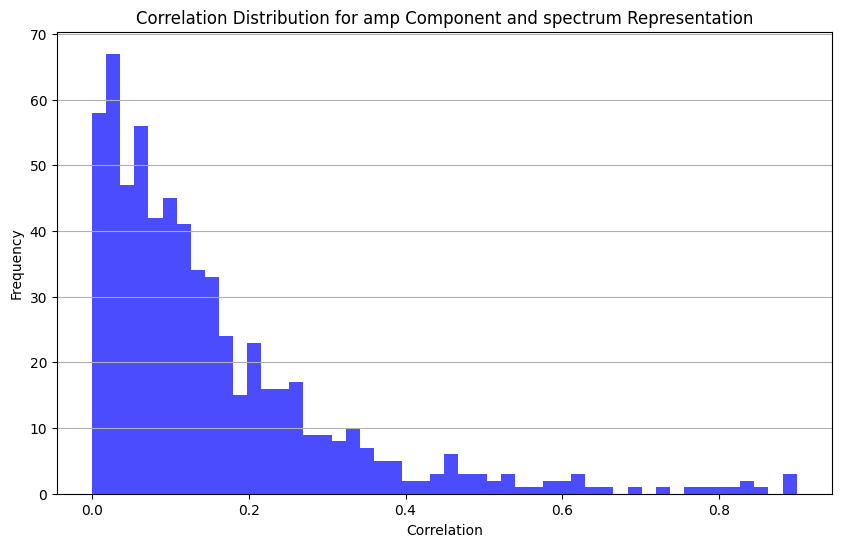

Processing spectrum for parameter filter_cutoff
Vectors shape: (401, 2049)
Average vector shape: (2049,)


Calculating correlations: 100%|██████████| 1000/1000 [01:37<00:00, 10.28it/s]


Skipped 374 entries due to inactive modulation.


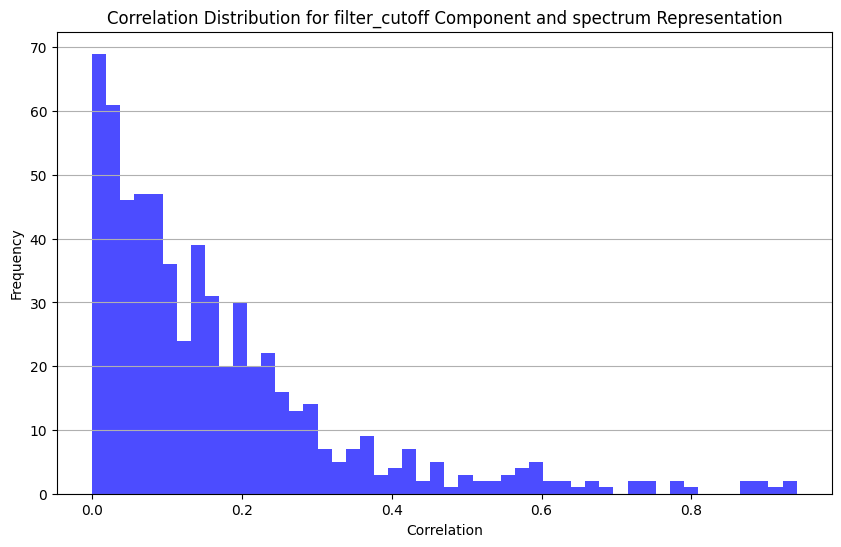

Processing spectrum for parameter osc_shape
Vectors shape: (478, 2049)
Average vector shape: (2049,)


Calculating correlations: 100%|██████████| 1000/1000 [01:34<00:00, 10.56it/s]


Skipped 373 entries due to inactive modulation.


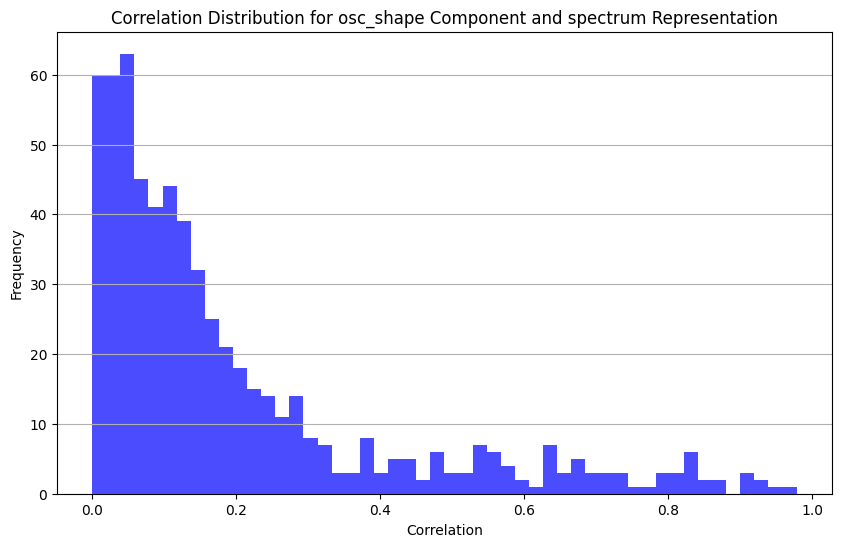

Processing cqt for parameter base_freq
Vectors shape: (417, 84)
Average vector shape: (84,)


Calculating correlations: 100%|██████████| 1000/1000 [01:13<00:00, 13.69it/s]


Skipped 387 entries due to inactive modulation.


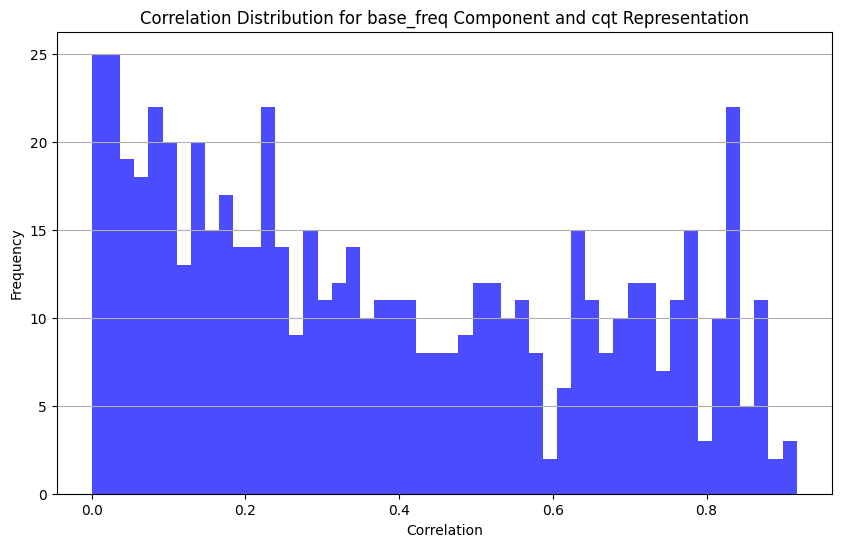

Processing cqt for parameter amp
Vectors shape: (498, 84)
Average vector shape: (84,)


Calculating correlations: 100%|██████████| 1000/1000 [01:11<00:00, 13.91it/s]


Skipped 366 entries due to inactive modulation.


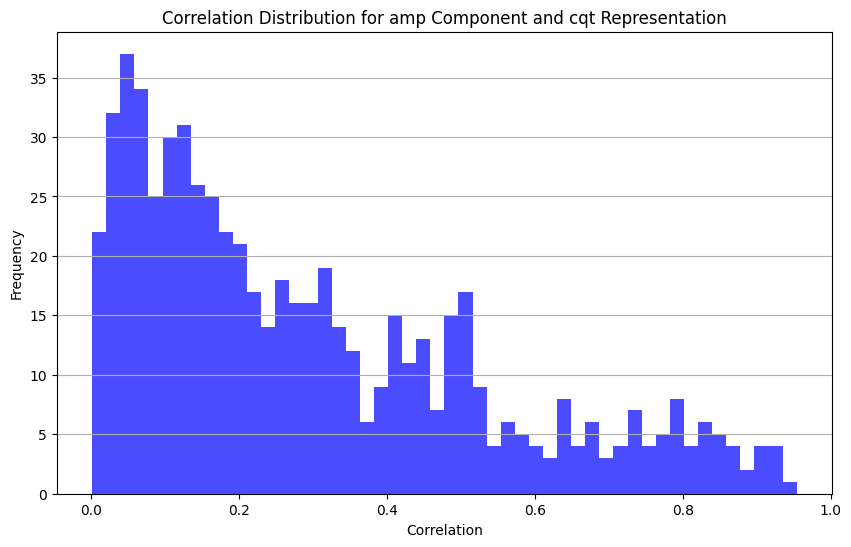

Processing cqt for parameter filter_cutoff
Vectors shape: (401, 84)
Average vector shape: (84,)


Calculating correlations: 100%|██████████| 1000/1000 [01:17<00:00, 12.84it/s]


Skipped 374 entries due to inactive modulation.


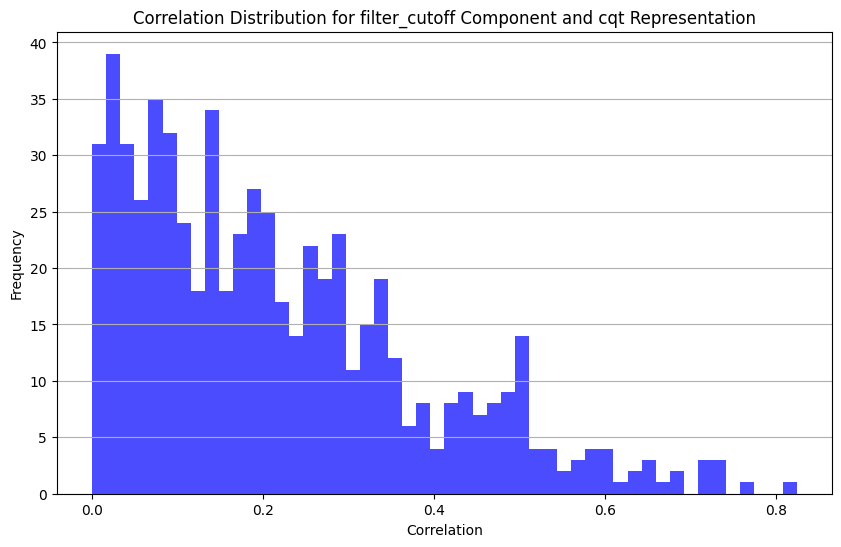

Processing cqt for parameter osc_shape
Vectors shape: (478, 84)
Average vector shape: (84,)


Calculating correlations: 100%|██████████| 1000/1000 [01:16<00:00, 13.13it/s]


Skipped 373 entries due to inactive modulation.


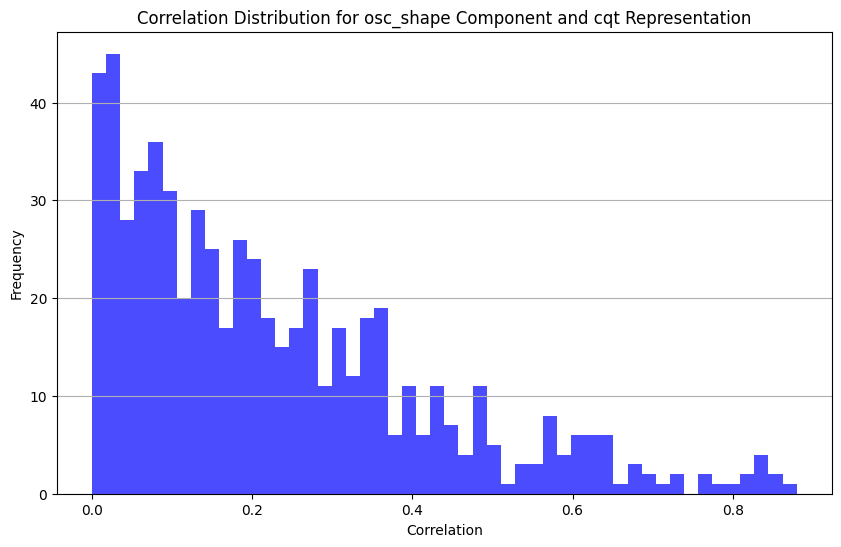

In [67]:
for REPR in list("dac mfcc music2latent spectrum cqt".split()):
    df = pd.read_parquet(f'{REPR}-components.parquet')
    df = deactivate_low_depth_components(df)

    for PARAM in list(synth.get_parameters().keys()):

        print(f"Processing {REPR} for parameter {PARAM}")

        vectors = df[f'{PARAM}_component'].dropna()
        vectors = np.vstack(vectors)

        print(f"Vectors shape: {vectors.shape}")

        filtered_vectors = filter_components_column(vectors)

        avg = np.mean(filtered_vectors, axis=0)
        
        print(f"Average vector shape: {avg.shape}")

        correlations = calc_all_correlations(avg, f'reprs_{REPR}.h5', PARAM)
        plot_correlation_histogram(correlations, title=f"Correlation Distribution for {PARAM} Component and {REPR} Representation")
    